In [ ]:
import torch
from torchvision.transforms import v2
from torch.utils.data import DataLoader

import numpy as np
from pathlib import Path
from __future__ import annotations

import v1.CarImageClass as CarImageClass
from v1.SSD_trainer import ConditionalIoUCrop, collate_detection, plot_losses, build_optimizer_and_scheduler


from v1.SSD_from_scratch import mySSD as oldSSD
from v1.SSD_trainer import SSD_train as oldSSD_train

from v2.model_files.SSD_from_scratch import mySSD as newSSD
from v2.training_files.SSD_trainer import SSD_train as newSSD_train



device = "cuda" if torch.cuda.is_available() else "cpu"

# desktop, laptop, ubuntu
machine = 'ubuntu'

# Setup path to data folder
if machine == 'laptop':
    folder_path = Path(r"C:\self-driving-car\data")
elif machine == 'desktop':
    folder_path = Path(r"C:\Udacity_car_data\data")
elif machine == 'ubuntu':
    folder_path = Path(r"/mnt/c/Udacity_car_data/data")

train_path = folder_path / "train"
test_path = folder_path / "test"

In [2]:
# transforms
train_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.RandomZoomOut(fill=0, p=0.5),       # Zoom out hurts model performance

    ConditionalIoUCrop(min_area_frac=0.02,   # threshold between "large" and "small"
                       small_min_scale=0.4,
                       large_min_scale=0.7,
                       max_scale=1.0,
                       min_aspect_ratio=0.75,
                       max_aspect_ratio=1.33,
                       small_sampler_options=(0.0, 0.05, 0.1, 2.0),
                       large_sampler_options=(0.05, 0.1, 0.3, 2.0),
                       trials=10),

    v2.SanitizeBoundingBoxes(min_size=1.0),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomPhotometricDistort(p=0.5),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

# 993 images
train_data = CarImageClass.ImageClass(targ_dir=train_path, transform=train_tfms, file_pct=0.05, rand_seed=724, include_area=False)
val_data = CarImageClass.ImageClass(targ_dir=train_path, transform=test_tfms, file_pct=0.05, rand_seed=412, include_area=False)

# need to put dataloaders on cpu to use pin_memory
BATCH_SIZE = 16
NUM_WORKERS = 8
# Create DataLoader's
train_dataloader = DataLoader(train_data, 
                              batch_size=BATCH_SIZE, 
                              shuffle=True, 
                              num_workers=NUM_WORKERS,
                              persistent_workers=True,
                              prefetch_factor=2,
                              pin_memory=True,
                              collate_fn=collate_detection,
                              multiprocessing_context="spawn",
                              )

val_dataloader = DataLoader(val_data, 
                            batch_size=BATCH_SIZE, 
                            shuffle=False,
                            num_workers=NUM_WORKERS,
                            persistent_workers=True,
                            prefetch_factor=2,
                            pin_memory=True,
                            collate_fn=collate_detection,
                            multiprocessing_context="spawn",
                            )


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0  |  mAP: 0.0004  |  Train loc loss: 4.5073  |  Train class loss: 5.7281  |  Test loc loss: 4.3977  |  Test class loss: 4.4800
Epoch: 1  |  mAP: 0.0069  |  Train loc loss: 3.4627  |  Train class loss: 3.1928  |  Test loc loss: 3.1229  |  Test class loss: 3.1453
Epoch: 2  |  mAP: 0.0096  |  Train loc loss: 2.6900  |  Train class loss: 2.8096  |  Test loc loss: 3.3429  |  Test class loss: 3.0380
Epoch: 3  |  mAP: 0.0244  |  Train loc loss: 2.2932  |  Train class loss: 2.6441  |  Test loc loss: 2.6269  |  Test class loss: 3.3221
Epoch: 4  |  mAP: 0.0205  |  Train loc loss: 1.9951  |  Train class loss: 2.4960  |  Test loc loss: 2.3333  |  Test class loss: 3.1181
Epoch: 5  |  mAP: 0.0179  |  Train loc loss: 1.8719  |  Train class loss: 2.4408  |  Test loc loss: 2.8380  |  Test class loss: 2.9782
Epoch: 6  |  mAP: 0.0000  |  Train loc loss: 1.7310  |  Train class loss: 2.2652  |  Test loc loss: 4.7026  |  Test class loss: 8.3900
Epoch: 7  |  mAP: 0.0294  |  Train loc loss: 2.5674  | 

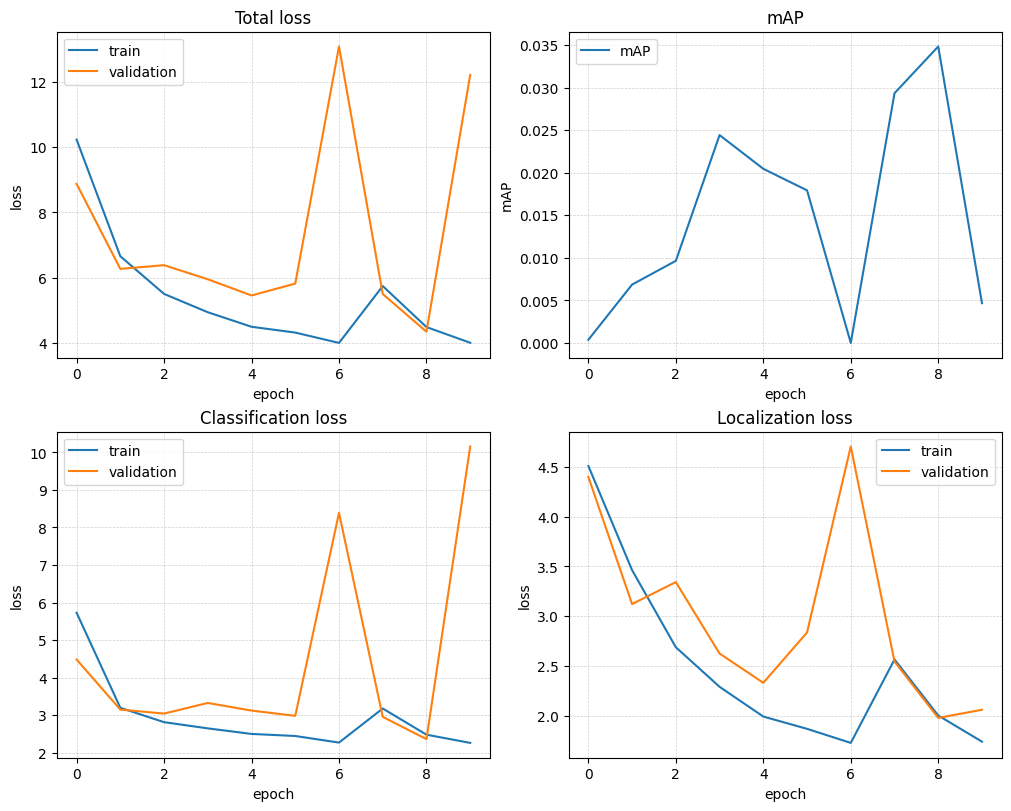

In [3]:
old_ssdmodel = oldSSD(class_to_idx_dict=train_data.class_to_idx, in_channels=3, variances=(0.1, 0.2)).to(device)

old_optimizer, old_scheduler = build_optimizer_and_scheduler(model=old_ssdmodel,
                                                     train_dataloader=train_dataloader,
                                                     max_epochs=150,
                                                     warmup_epochs=5,
                                                     base_lr=0.003,
                                                     min_lr=1e-6,
                                                     momentum=0.9,
                                                     weight_decay=0.005)

# new model only
# scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

old_results = oldSSD_train(model=old_ssdmodel,
                    train_dataloader=train_dataloader,
                    test_dataloader=val_dataloader,
                    optimizer=old_optimizer,
                    scheduler=old_scheduler,
                    sched_step_w_opt=True,
                    iou_thresh=0.4,
                    neg_pos_ratio=3.0,
                    score_thresh=0.2,
                    nms_thresh=0.3,
                    max_detections_per_img=100,
                    epochs=10,
                    early_stopping_rounds=None,
                    device=device,
                    save_model=False,
                    epoch_save_interval=None,
                    SAVE_DIR=None,
                    timing=True,
                    past_train_dict=None,
                    )

plot_losses(old_results)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1  |  mAP: 0.0013  |  Train loc loss: 4.5233  |  Train class loss: 5.6942  |  Test loc loss: 4.0894  |  Test class loss: 3.7240
Epoch: 2  |  mAP: 0.0190  |  Train loc loss: 3.3872  |  Train class loss: 3.2585  |  Test loc loss: 3.1149  |  Test class loss: 2.9439
Epoch: 3  |  mAP: 0.0086  |  Train loc loss: 2.6516  |  Train class loss: 2.8058  |  Test loc loss: 2.6973  |  Test class loss: 3.5732
Epoch: 4  |  mAP: 0.0000  |  Train loc loss: 2.2897  |  Train class loss: 2.6858  |  Test loc loss: 5.9867  |  Test class loss: 18.1714
Epoch: 5  |  mAP: 0.0225  |  Train loc loss: 2.2852  |  Train class loss: 2.8984  |  Test loc loss: 2.3929  |  Test class loss: 3.2334
Epoch: 6  |  mAP: 0.0002  |  Train loc loss: 2.0023  |  Train class loss: 2.4667  |  Test loc loss: 3.5702  |  Test class loss: 11.9168
Epoch: 7  |  mAP: 0.0330  |  Train loc loss: 1.9743  |  Train class loss: 2.5986  |  Test loc loss: 1.8580  |  Test class loss: 2.4677
Epoch: 8  |  mAP: 0.0007  |  Train loc loss: 1.6859  

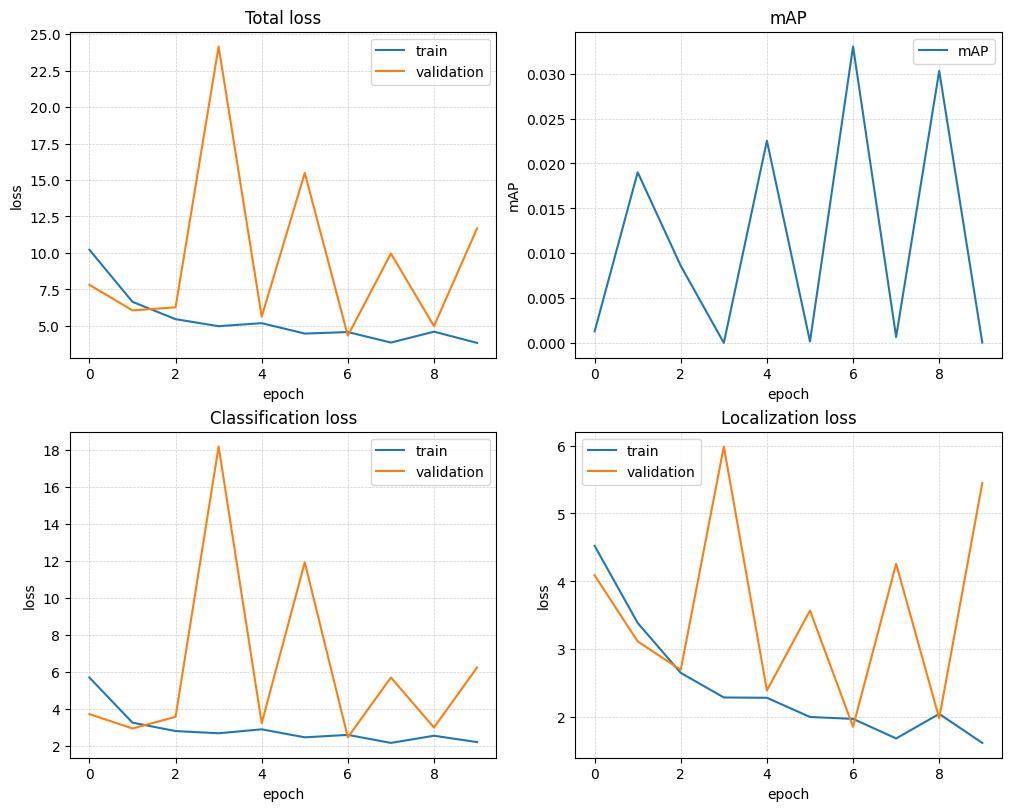

In [4]:
new_ssdmodel = newSSD(class_to_idx_dict=train_data.class_to_idx, in_channels=3, variances=(0.1, 0.2)).to(device)

new_optimizer, new_scheduler = build_optimizer_and_scheduler(model=new_ssdmodel,
                                                     train_dataloader=train_dataloader,
                                                     max_epochs=150,
                                                     warmup_epochs=5,
                                                     base_lr=0.003,
                                                     min_lr=1e-6,
                                                     momentum=0.9,
                                                     weight_decay=0.005)

# new model only
scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

new_results = newSSD_train(model=new_ssdmodel,
                    train_dataloader=train_dataloader,
                    test_dataloader=val_dataloader,
                    optimizer=new_optimizer,
                    scheduler=new_scheduler,
                    scaler=scaler,
                    sched_step_w_opt=True,
                    iou_thresh=0.4,
                    neg_pos_ratio=3.0,
                    score_thresh=0.2,
                    nms_thresh=0.3,
                    max_detections_per_img=100,
                    epochs=10,
                    early_stopping_rounds=None,
                    device=device,
                    save_model=False,
                    epoch_save_interval=None,
                    SAVE_DIR=None,
                    timing=True,
                    past_train_dict=None,
                    )

plot_losses(new_results)

In [ ]:
avg_old_train = {
    k: round(sum(d[k] for d in old_results['training timing']) / len(old_results['training timing']),5)
    for k in old_results['training timing'][0]
}

avg_old_test = {
    k: round(sum(d[k] for d in old_results['testing timing']) / len(old_results['testing timing']),5)
    for k in old_results['testing timing'][0]
}


print(f"Old training: {avg_old_train}")
print(f"Old testing: {avg_old_test}")

Old training: {'to device': 0.00289, 'model forward': 0.12417, 'build targets': 0.04749}
Old testing: {'to device': 0.0024, 'model forward': 0.13316, 'build targets': 0.0402, 'compute loss': 0.00695, 'model.predict': 1.20504, 'mAP time': 7.77382}


In [6]:
avg_new_train = {
    k: round(sum(d[k] for d in new_results['training timing']) / len(new_results['training timing']),5)
    for k in new_results['training timing'][0]
}

avg_new_test = {
    k: round(sum(d[k] for d in new_results['testing timing']) / len(new_results['testing timing']),5)
    for k in new_results['testing timing'][0]
}


print(f"New training: {avg_new_train}")
print(f"New testing: {avg_new_test}")

New training: {'to device': 0.00274, 'model forward': 0.07512, 'build targets': 0.07358, 'compute loss': 0.00474}
New testing: {'to device': 0.00236, 'model forward': 0.06733, 'build targets': 0.05733, 'compute loss': 0.00434, 'model.predict': 0.05891, 'mAP time': 9.1483}
